In [37]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Literal
import random

In [38]:
class JourneyState(TypedDict):
    current_location: str

In [ ]:
def coimbatore(state: JourneyState) -> JourneyState:
    print("Starting from Coimbatore")
    return {"current_location": "Departed from Coimbatore"}

def salem(state: JourneyState) -> JourneyState:
    print("Arrived at salem")
    return {"current_location": "Visited Salem"}

def trichy(state: JourneyState) -> JourneyState:
    print("Arrived at Trichy")
    return {"current_location": "Visited Trichy"}

def intermediate_city(state: JourneyState) -> Literal["trichy", "salem"]:
    print(f"Deciding route... Last update: {state["current_location"]}")
    if random.random() < 0.5:
        print("--> Route Selected: Trichy")
        return "trichy"
    else: 
        print("--> Route Selected: Salem")
        return "salem"

In [40]:
builder = StateGraph(JourneyState)

builder.add_node("coimbatore", coimbatore)
builder.add_node("trichy", trichy)
builder.add_node("salem", salem)

In [41]:
builder.add_edge(START, "coimbatore")
builder.add_conditional_edges("coimbatore", intermediate_city)
builder.add_edge("salem", END)
builder.add_edge("trichy", END)

In [42]:
graph = builder.compile()

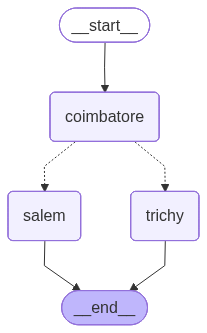

In [43]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
graph.invoke({"current_location": "Coimbatore"})

Starting from Coimbatore
Deciding route... Last update: Departed from Coimbatore
--> Route Selected: Salem
Arrived at salem


{'current_location': 'Visited Salem'}